In [1]:
!git clone https://github.com/AGupta-23/RetinaVision.git
%cd RetinaVision

Cloning into 'RetinaVision'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 44 (delta 10), reused 40 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 4.37 MiB | 56.66 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/kaggle/working/RetinaVision


In [2]:
from src.model import build_model, count_trainable_params

model = build_model()
trainable, total, percent = count_trainable_params(model)
print(f"Trainable params: {trainable:,} / {total:,} ({percent:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


Trainable params: 14,966,785 / 23,510,081 (63.7%)


In [3]:
from src.dataset import RetinaDataset, preprocess_transform

In [4]:
import torch
import torch.nn as nn
from torch.optim import Adam

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Load cleaned labels
df = pd.read_csv("/kaggle/working/RetinaVision/data/clean_labels.csv")

# Stratified split: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

IMAGE_DIR = "/kaggle/input/competitions/aptos2019-blindness-detection/train_images"  # adjust if your path differs

train_dataset = RetinaDataset(train_df, IMAGE_DIR, transform=preprocess_transform)
val_dataset = RetinaDataset(val_df, IMAGE_DIR, transform=preprocess_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test (held out): {len(test_df)}")

Train: 2563 | Val: 549 | Test (held out): 550


In [6]:
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=1e-4)

In [7]:
import copy
import time


num_epochs = 15
best_val_loss = float("inf")

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(num_epochs):
    start = time.time()

    # ---- TRAIN ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)  # shape [B,1] to match logit output

        optimizer.zero_grad()
        outputs = model(images)              # raw logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---- VALIDATE ----
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {time.time()-start:.1f}s")

    # ---- SAVE BEST CHECKPOINT ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  ↳ New best model saved (val_loss={val_loss:.4f})")

Epoch 1/15 | Train Loss: 0.2521 Acc: 0.9348 | Val Loss: 0.1195 Acc: 0.9563 | Time: 209.9s
  ↳ New best model saved (val_loss=0.1195)
Epoch 2/15 | Train Loss: 0.0682 Acc: 0.9789 | Val Loss: 0.0656 Acc: 0.9763 | Time: 180.7s
  ↳ New best model saved (val_loss=0.0656)
Epoch 3/15 | Train Loss: 0.0340 Acc: 0.9871 | Val Loss: 0.0584 Acc: 0.9800 | Time: 179.8s
  ↳ New best model saved (val_loss=0.0584)
Epoch 4/15 | Train Loss: 0.0205 Acc: 0.9906 | Val Loss: 0.0834 Acc: 0.9727 | Time: 178.4s
Epoch 5/15 | Train Loss: 0.0113 Acc: 0.9945 | Val Loss: 0.0910 Acc: 0.9709 | Time: 178.6s
Epoch 6/15 | Train Loss: 0.0119 Acc: 0.9945 | Val Loss: 0.0829 Acc: 0.9763 | Time: 183.9s
Epoch 7/15 | Train Loss: 0.0113 Acc: 0.9953 | Val Loss: 0.0769 Acc: 0.9836 | Time: 179.9s
Epoch 8/15 | Train Loss: 0.0081 Acc: 0.9969 | Val Loss: 0.0929 Acc: 0.9781 | Time: 179.2s
Epoch 9/15 | Train Loss: 0.0044 Acc: 0.9984 | Val Loss: 0.1253 Acc: 0.9690 | Time: 180.0s
Epoch 10/15 | Train Loss: 0.0045 Acc: 0.9984 | Val Loss: 0.10

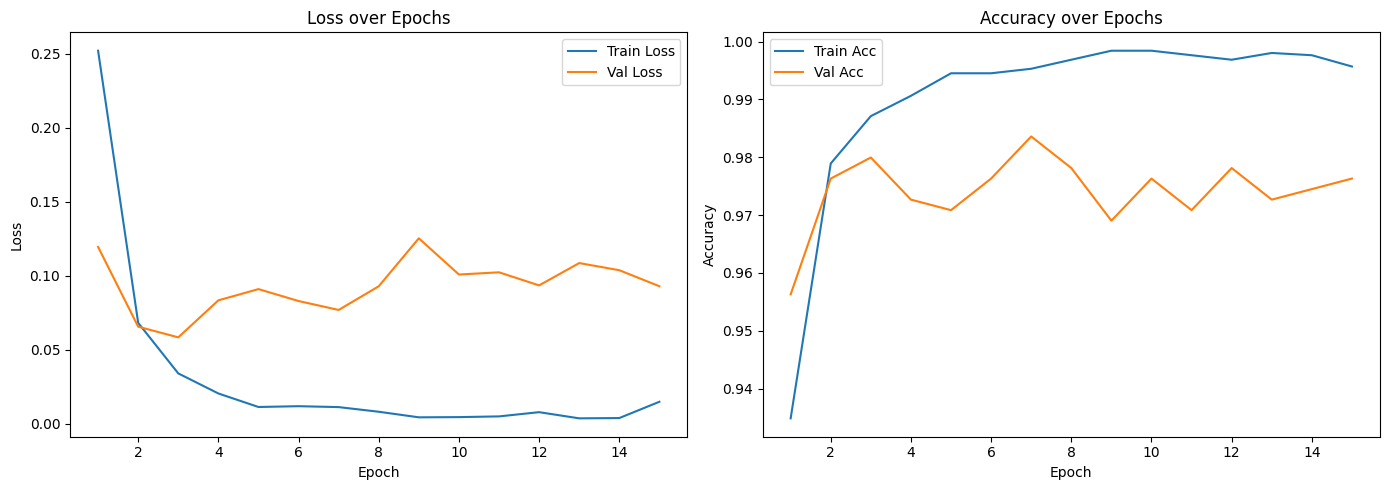

In [8]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("/training_curves.png", dpi=150)
plt.show()

In [9]:
import json
with open("/history.json", "w") as f:
    json.dump(history, f, indent=2)

In [10]:
import os
print("Current directory:", os.getcwd())
!find /kaggle/working -name "best_model.pth"

Current directory: /kaggle/working/RetinaVision
/kaggle/working/RetinaVision/best_model.pth


In [11]:
import os
print("Current directory:", os.getcwd())
!find /kaggle/working -name "history.json"

Current directory: /kaggle/working/RetinaVision


In [12]:
import os
print("Current directory:", os.getcwd())
!find /kaggle/working -name "training_curves.png"

Current directory: /kaggle/working/RetinaVision
